### **Description**

This recipe shows how to regrid the monthly-mean sea surface temperature outputs from the National Oceanography Centre Near-Present-Day global eORCA025 configuration of NEMO forced using JRA55-do from 1976-2024.

For more details on this model configuration and the available outputs, users can explore the Near-Present-Day documentation [here](https://noc-msm.github.io/NOC_Near_Present_Day/).

---
### **Background**
[**xESMF**](https://xesmf.readthedocs.io/en/stable/index.html) is a Python library to regrid geospatial data using the **ESMPy** regridding engine. The library supports both structured rectilinear grids and fully curvilinear grids supplied as standardised `xarray.Datasets`.

Bilinear interpolation is the most commonly used regridding method for smooth scalar fields, such as temperature, salinity and sea surface height.

For fluxes or extensive variables, conservative regridding methods are preferred so that integrals are preserved following interpolation. For example, conservative interpolation is typically used when we need to conserve global or regional budgets through regridding.

---

In [1]:
# -- Import required packages -- #
import matplotlib.pyplot as plt
import xarray as xr
import xesmf as xe

from nemo_cookbook import NEMODataTree

xr.set_options(display_style="text")

### **Using Dask**

**Optional: Connect Client to Dask Local Cluster to run analysis in parallel.**

**Note:** Although using Dask is not strictly necessary for this simple example using eORCA025, if we wanted to generalise this recipe to eORCA12 or eORCA36 outputs, using Dask would be essential to avoid unnecessary slow calculations using only a single process.

In [ ]:
# -- Initialise Dask Local Cluster -- #
import os

import dask
from dask.distributed import Client, LocalCluster

# Update temporary directory for Dask workers:
dask.config.set({'temporary_directory': f"{os.getcwd()}/dask_tmp",
                 'local_directory': f"{os.getcwd()}/dask_tmp"
                 })

# Create Local Cluster:
cluster = LocalCluster(n_workers=4, threads_per_worker=3, memory_limit='5GB')
client = Client(cluster)
client

### **Accessing NEMO Model Data**
**Let's begin by loading the grid variables for our eORCA025 NEMO model from the [JASMIN Object Store](https://help.jasmin.ac.uk/docs/short-term-project-storage/using-the-jasmin-object-store/)**. 

**Alternatively, you can replace the ``domain_filepath`` below with a file path to your domain_cfg.nc file and read this with xarray's ``open_dataset()`` function.**

In [2]:
# Define directory path to ancillary files:
domain_filepath = "https://noc-msm-o.s3-ext.jc.rl.ac.uk/npd-eorca025-jra55v1/domain_cfg"

# Open eORCA025 NEMO model domain_cfg:
ds_domain = xr.open_zarr(domain_filepath, consolidated=True, chunks={})

ds_domain

<xarray.Dataset> Size: 10GB
Dimensions:       (y: 1206, x: 1440, nav_lev: 75)
Coordinates:
  * y             (y) int64 10kB 0 1 2 3 4 5 6 ... 1200 1201 1202 1203 1204 1205
  * x             (x) int64 12kB 0 1 2 3 4 5 6 ... 1434 1435 1436 1437 1438 1439
  * nav_lev       (nav_lev) int64 600B 0 1 2 3 4 5 6 7 ... 68 69 70 71 72 73 74
Data variables: (12/49)
    atlmsk        (y, x) int8 2MB dask.array<chunksize=(603, 720), meta=np.ndarray>
    bathy_metry   (y, x) float32 7MB dask.array<chunksize=(603, 720), meta=np.ndarray>
    bottom_level  (y, x) int32 7MB dask.array<chunksize=(603, 720), meta=np.ndarray>
    e1f           (y, x) float64 14MB dask.array<chunksize=(603, 720), meta=np.ndarray>
    e1t           (y, x) float64 14MB dask.array<chunksize=(603, 720), meta=np.ndarray>
    e1u           (y, x) float64 14MB dask.array<chunksize=(603, 720), meta=np.ndarray>
    ...            ...
    top_level     (y, x) int32 7MB dask.array<chunksize=(603, 720), meta=np.ndarray>
    umask         (nav_lev, y, x) int8 130MB dask.array<chunksize=(1, 603, 720), meta=np.ndarray>
    umaskutil     (y, x) int8 2MB dask.array<chunksize=(603, 720), meta=np.ndarray>
    vmask         (nav_lev, y, x) int8 130MB dask.array<chunksize=(1, 603, 720), meta=np.ndarray>
    vmaskutil     (y, x) int8 2MB dask.array<chunksize=(603, 720), meta=np.ndarray>
    wmask         (nav_lev, y, x) int8 130MB dask.array<chunksize=(1, 603, 720), meta=np.ndarray>
Attributes:
    CfgName:    orca
    CfgIndex:   25
    Iperio:     1
    Jperio:     0
    NFold:      1
    NFtype:     T
    VertCoord:  zps
    IsfCav:     0
    file_name:  mesh_mask.nc
    TimeStamp:  08/11/2022 13:15:21 -0000

**Next, we need to import the sea surface temperature stored at T-points in a single dataset.**

In [3]:
# Define directory path to model output files:
gridT_url = "https://noc-msm-o.s3-ext.jc.rl.ac.uk/npd-eorca025-jra55v1/T1m_3d"

# Construct NEMO model T-grid dataset, including sea surface temperature:
ds_gridT = xr.open_zarr(gridT_url, consolidated=True, chunks={})

ds_gridT

<xarray.Dataset> Size: 196GB
Dimensions:                (time_counter: 577, y: 1206, x: 1440, axis_nbounds: 2)
Coordinates:
  * time_counter           (time_counter) datetime64[ns] 5kB 1976-01-16T12:00...
    time_centered          (time_counter) datetime64[ns] 5kB dask.array<chunksize=(1,), meta=np.ndarray>
    nav_lat                (y, x) float64 14MB dask.array<chunksize=(1206, 1440), meta=np.ndarray>
    nav_lon                (y, x) float64 14MB dask.array<chunksize=(1206, 1440), meta=np.ndarray>
Dimensions without coordinates: y, x, axis_nbounds
Data variables: (12/51)
    berg_latent_heat_flux  (time_counter, y, x) float32 4GB dask.array<chunksize=(1, 1206, 1440), meta=np.ndarray>
    empmr                  (time_counter, y, x) float32 4GB dask.array<chunksize=(1, 1206, 1440), meta=np.ndarray>
    evs                    (time_counter, y, x) float32 4GB dask.array<chunksize=(1, 1206, 1440), meta=np.ndarray>
    ficeberg               (time_counter, y, x) float32 4GB dask.array<chunksize=(1, 1206, 1440), meta=np.ndarray>
    friver                 (time_counter, y, x) float32 4GB dask.array<chunksize=(1, 1206, 1440), meta=np.ndarray>
    fsitherm               (time_counter, y, x) float32 4GB dask.array<chunksize=(1, 1206, 1440), meta=np.ndarray>
    ...                     ...
    tnpeo                  (time_counter, y, x) float32 4GB dask.array<chunksize=(1, 1206, 1440), meta=np.ndarray>
    tos_con                (time_counter, y, x) float32 4GB dask.array<chunksize=(1, 1206, 1440), meta=np.ndarray>
    tossq_con              (time_counter, y, x) float32 4GB dask.array<chunksize=(1, 1206, 1440), meta=np.ndarray>
    ttrd_qns_li            (time_counter, y, x) float32 4GB dask.array<chunksize=(1, 1206, 1440), meta=np.ndarray>
    zos                    (time_counter, y, x) float32 4GB dask.array<chunksize=(1, 1206, 1440), meta=np.ndarray>
    zossq                  (time_counter, y, x) float32 4GB dask.array<chunksize=(1, 1206, 1440), meta=np.ndarray>
Attributes:
    name:         OUTPUT/eORCA025_1m_grid_T
    description:  ocean T grid variables
    title:        ocean T grid variables
    Conventions:  CF-1.6
    timeStamp:    2024-Dec-07 20:28:00 GMT
    uuid:         4eebd27d-0e9f-4117-9049-09723ef43258

### **Creating a NEMODataTree**

**Next, let's create a NEMODataTree to store our domain and gridT variables for the eORCA025 model.**

In [4]:
# Define dictionary of grid datasets defining eORCA025 parent model domain with no child/grand-child nests:
datasets = {"parent": {"domain": ds_domain, "gridT": ds_gridT}}

# Initialise a new NEMODataTree whose parent domain is zonally periodic & north-folding on T-points:
nemo = NEMODataTree.from_datasets(datasets=datasets, iperio=True, nftype="T", read_mask=False)

nemo

<xarray.DataTree 'NEMO model'>
Group: /
│   Dimensions:               (time_counter: 577, axis_nbounds: 2)
│   Coordinates:
│     * time_counter          (time_counter) datetime64[ns] 5kB 1976-01-16T12:00:...
│       time_centered         (time_counter) datetime64[ns] 5kB dask.array<chunksize=(1,), meta=np.ndarray>
│   Dimensions without coordinates: axis_nbounds
│   Data variables:
│       time_centered_bounds  (time_counter, axis_nbounds) datetime64[ns] 9kB dask.array<chunksize=(1, 2), meta=np.ndarray>
│       time_counter_bounds   (time_counter, axis_nbounds) datetime64[ns] 9kB dask.array<chunksize=(1, 2), meta=np.ndarray>
│   Attributes:
│       nftype:   T
│       iperio:   True
├── Group: /gridT
│       Dimensions:                (time_counter: 577, j: 1206, i: 1440,
│                                   axis_nbounds: 2, k: 75)
│       Coordinates:
│           time_centered          (time_counter) datetime64[ns] 5kB dask.array<chunksize=(1,), meta=np.ndarray>
│         * j                      (j) int64 10kB 1 2 3 4 5 ... 1202 1203 1204 1205 1206
│         * i                      (i) int64 12kB 1 2 3 4 5 ... 1436 1437 1438 1439 1440
│           gphit                  (j, i) float64 14MB dask.array<chunksize=(603, 720), meta=np.ndarray>
│           glamt                  (j, i) float64 14MB dask.array<chunksize=(603, 720), meta=np.ndarray>
│         * k                      (k) int64 600B 1 2 3 4 5 6 7 ... 69 70 71 72 73 74 75
│       Dimensions without coordinates: axis_nbounds
│       Data variables: (12/55)
│           berg_latent_heat_flux  (time_counter, j, i) float32 4GB dask.array<chunksize=(1, 1206, 1440), meta=np.ndarray>
│           empmr                  (time_counter, j, i) float32 4GB dask.array<chunksize=(1, 1206, 1440), meta=np.ndarray>
│           evs                    (time_counter, j, i) float32 4GB dask.array<chunksize=(1, 1206, 1440), meta=np.ndarray>
│           ficeberg               (time_counter, j, i) float32 4GB dask.array<chunksize=(1, 1206, 1440), meta=np.ndarray>
│           friver                 (time_counter, j, i) float32 4GB dask.array<chunksize=(1, 1206, 1440), meta=np.ndarray>
│           fsitherm               (time_counter, j, i) float32 4GB dask.array<chunksize=(1, 1206, 1440), meta=np.ndarray>
│           ...                     ...
│           zos                    (time_counter, j, i) float32 4GB dask.array<chunksize=(1, 1206, 1440), meta=np.ndarray>
│           zossq                  (time_counter, j, i) float32 4GB dask.array<chunksize=(1, 1206, 1440), meta=np.ndarray>
│           e1t                    (j, i) float64 14MB dask.array<chunksize=(603, 720), meta=np.ndarray>
│           e2t                    (j, i) float64 14MB dask.array<chunksize=(603, 720), meta=np.ndarray>
│           tmask                  (k, j, i) bool 130MB dask.array<chunksize=(75, 603, 720), meta=np.ndarray>
│           tmaskutil              (j, i) bool 2MB dask.array<chunksize=(603, 720), meta=np.ndarray>
│       Attributes:
│           nftype:   T
│           iperio:   True
├── Group: /gridU
│       Dimensions:       (j: 1206, i: 1440, k: 75)
│       Coordinates:
│         * j             (j) int64 10kB 1 2 3 4 5 6 7 ... 1201 1202 1203 1204 1205 1206
│         * i             (i) float64 12kB 1.5 2.5 3.5 ... 1.438e+03 1.44e+03 1.44e+03
│           gphiu         (j, i) float64 14MB dask.array<chunksize=(603, 720), meta=np.ndarray>
│           glamu         (j, i) float64 14MB dask.array<chunksize=(603, 720), meta=np.ndarray>
│         * k             (k) int64 600B 1 2 3 4 5 6 7 8 9 ... 68 69 70 71 72 73 74 75
│       Data variables:
│           e1u           (j, i) float64 14MB dask.array<chunksize=(603, 720), meta=np.ndarray>
│           e2u           (j, i) float64 14MB dask.array<chunksize=(603, 720), meta=np.ndarray>
│           umask         (k, j, i) bool 130MB False False False ... False False False
│           umaskutil     (j, i) bool 2MB False False False False ... False False False
│      

### **Exploring Sea Surface Temperature**

**Now we have constructed our `NEMODataTree`, let's take a look at an example snapshot of monthly-mean sea surface temperature by creating a `NEMODataArray`.**

We can see that sea surface temperature `tos_con` is defined on a curvilinear grid, where latitude `gphit` and longitude `glamt` of NEMO T-grid points are functions of the orthogonal grid dimensions `i` and `j`.

In [5]:
# Access sea surface temperature [C] as a NEMODataArray:
nemo['gridT/tos_con']

<NEMODataTree 'NEMO model'>
  <NEMODataArray 'tos_con' (Domain: '.', Grid: 'gridT', Grid Type: 'T')>

<xarray.DataArray 'tos_con' (time_counter: 577, j: 1206, i: 1440)> Size: 4GB
dask.array<open_dataset-tos_con, shape=(577, 1206, 1440), dtype=float32, chunksize=(1, 1206, 1440), chunktype=numpy.ndarray>
Coordinates:
  * time_counter   (time_counter) datetime64[ns] 5kB 1976-01-16T12:00:00 ... ...
    time_centered  (time_counter) datetime64[ns] 5kB dask.array<chunksize=(1,), meta=np.ndarray>
  * j              (j) int64 10kB 1 2 3 4 5 6 ... 1201 1202 1203 1204 1205 1206
  * i              (i) int64 12kB 1 2 3 4 5 6 ... 1435 1436 1437 1438 1439 1440
    gphit          (j, i) float64 14MB dask.array<chunksize=(603, 720), meta=np.ndarray>
    glamt          (j, i) float64 14MB dask.array<chunksize=(603, 720), meta=np.ndarray>
Attributes:
    standard_name:       sea_surface_temperature
    long_name:           sea_surface_conservative_temperature
    units:               degC
    online_operation:    average
    interval_operation:  1800 s
    interval_write:      1 month
    cell_methods:        time: mean (interval: 1800 s)

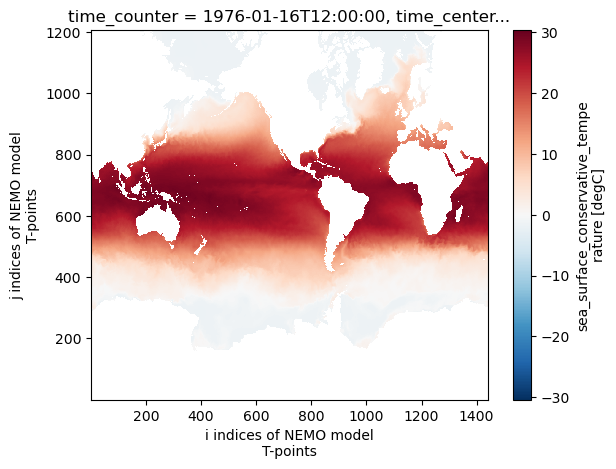

In [6]:
# Plotting an example snapshot monthly-mean sea surface temperature [C]:
nemo['gridT/tos_con'].isel(time_counter=0).plot()

### **Bilinear Regridding using xESMF**

**Next, let's regrid our snapshot of monthly-mean sea surface temperature to a regular 2 x 2 rectilinear grid.**

To do this, we can use the `NEMODataArray.to_xesmf()` accessor, which returns NEMO model variables defined on scalar T-points as an xESMF compataible dataset including the following coordinates:

* `lon` - longitude of T-grid cell centers .
* `lat` - latitude of T-grid cell centers.
* `lon_b` - longitude of T-grid cell corners (lower left F-grid points).
* `lat_b` - longitude of T-grid cell corners (lower left F-grid points).

By default, the `to_xesmf()` accessor also returns a 2-dimensional land-sea mask (`mask`) to support masked regridding with **xESMF**. This ensures source land grid cells do not contribute any weight to any target grid cell. Following ESMF convention, `ocean = 1` and `land = 0` consistent with NEMO land-sea masks.

In [7]:
# Access sea surface temperature as an xESMF-compatible dataset:
ds_tos_con = nemo['gridT/tos_con'].isel(time_counter=0).to_xesmf(mask=True)

ds_tos_con

<xarray.Dataset> Size: 64MB
Dimensions:        (j: 1205, i: 1440, j_b: 1206, i_b: 1441)
Coordinates:
  * j              (j) int64 10kB 2 3 4 5 6 7 ... 1201 1202 1203 1204 1205 1206
  * i              (i) int64 12kB 1 2 3 4 5 6 ... 1435 1436 1437 1438 1439 1440
    lat            (j, i) float64 14MB dask.array<chunksize=(602, 720), meta=np.ndarray>
    lon            (j, i) float64 14MB dask.array<chunksize=(602, 720), meta=np.ndarray>
  * j_b            (j_b) float64 10kB 1.5 2.5 3.5 ... 1.206e+03 1.206e+03
  * i_b            (i_b) float64 12kB 1.44e+03 1.5 2.5 ... 1.44e+03 1.44e+03
    lon_b          (j_b, i_b) float64 14MB dask.array<chunksize=(603, 1), meta=np.ndarray>
    lat_b          (j_b, i_b) float64 14MB dask.array<chunksize=(603, 1), meta=np.ndarray>
    time_counter   datetime64[ns] 8B 1976-01-16T12:00:00
    time_centered  datetime64[ns] 8B dask.array<chunksize=(), meta=np.ndarray>
Data variables:
    tos_con        (j, i) float32 7MB dask.array<chunksize=(1205, 1440), meta=np.ndarray>
    mask           (j, i) bool 2MB dask.array<chunksize=(602, 720), meta=np.ndarray>

**Next, let's use xESMF to define a global rectilinear grid and regrid the sea surface temperature curvilinear NEMO model grid using bilinear interpolation:**

To account for the zonal periodicity of a global eORCA025 domain, we use `periodic=True` for non-conservative regridding. We also use `ignore_degenerate=True` to handle the possibility of geometrically degenerate grid cells in the vicinity of the north fold on eORCA025 tripolar grid. Without this option, we can encounter errors in weight generation.

Given that **xESMF** only supports 2-dimensional masks, we also include `skipna=True` and `na_thres=0.5` to support adaptive masking. This allows the weights for a 2-dimensional field (i.e., single vertical level of a NEMO ocean model) to be reused across multiple levels which vary only in terms of their land-sea masking. Adaptive masking either defines a target cell to be NaN if the ratio of missing values > `na_thres` or renormalises the target grid cell value if the ratio of missing values < `na_thres`. By default, a target grid cell is only set to NaN if *all* source grid cells are NaN (i.e., `na_thres=1.0`).

Here, we use `na_thres=0.5`, meaning a target grid cell is set to NaN if more than 50% of contributing source grid cells are NaN.

For more information, visit the [**xESMF documentation**](https://xesmf.readthedocs.io/en/stable/index.html).

In [8]:
# Define regular 2x2 global rectlinear grid:
ds_out = xe.util.grid_global(d_lat=2, d_lon=2)

# Define xESMF bilinear regridder with a zonally periodic domain:
regridder = xe.Regridder(ds_tos_con,
                         ds_out,
                         "bilinear",
                         periodic=True, # Zonally periodic domain.
                         ignore_degenerate=True, # Ignore degenerate grid cells due to north folding.
                         unmapped_to_nan=True, # Set unmapped points to NaN instead of raising an error.
                         )

# Regrid NEMO model sea surface temperature to regular global grid: 
ds_bilinear = regridder(ds_tos_con, skipna=True, na_thres=0.5)

ds_bilinear

<xarray.Dataset> Size: 28MB
Dimensions:        (y: 90, x: 180, j_b: 1206, i_b: 1441)
Coordinates:
    lon            (y, x) float64 130kB -179.0 -177.0 -175.0 ... 177.0 179.0
    lat            (y, x) float64 130kB -89.0 -89.0 -89.0 ... 89.0 89.0 89.0
  * j_b            (j_b) float64 10kB 1.5 2.5 3.5 ... 1.206e+03 1.206e+03
  * i_b            (i_b) float64 12kB 1.44e+03 1.5 2.5 ... 1.44e+03 1.44e+03
    lon_b          (j_b, i_b) float64 14MB dask.array<chunksize=(603, 1), meta=np.ndarray>
    lat_b          (j_b, i_b) float64 14MB dask.array<chunksize=(603, 1), meta=np.ndarray>
    time_counter   datetime64[ns] 8B 1976-01-16T12:00:00
    time_centered  datetime64[ns] 8B dask.array<chunksize=(), meta=np.ndarray>
Dimensions without coordinates: y, x
Data variables:
    tos_con        (y, x) float64 130kB dask.array<chunksize=(90, 180), meta=np.ndarray>
    mask           (y, x) float64 130kB dask.array<chunksize=(90, 180), meta=np.ndarray>
Attributes:
    regrid_method:  bilinear

### **Conservative Regridding using xESMF**

**We have seen how to bilinearly interpolate sea surface temperature onto a regular rectilinear grid. Next, let's compare this to using a conservative interpolation method:**

Here, we use the `conservative_normed` method to avoid deflation by land grid cells. For example, if a target grid cell is comprised of 25% ocean and 75% land, the resulting value should only be normalised by the cell area that is covered by unmasked ocean source grid cells (25%) to avoid deflation by the 75% of land grid cells.

**Note when `method="conservative"` and `na_thres=1.0` (default), this is equivalent of using `method="conservative_normed"` with an explicit `mask`.**

In [9]:
# Define xESMF conservative regridder with a zonally periodic domain:
regridder = xe.Regridder(ds_tos_con,
                         ds_out,
                         "conservative_normed", # Normalise by ocean grid cell fraction not total grid cell area.
                         periodic=False, # xESMF conservative regridder overwrites zonal periodicity -> False.
                         ignore_degenerate=True, # Ignore degenerate grid cells due to north folding.
                         unmapped_to_nan=True, # Replace zeros by NaN for weight matrix entries of unmapped target grid cells.
                         )

# Regrid NEMO model sea surface temperature to regular global grid:
ds_conservative = regridder(ds_tos_con, skipna=True, na_thres=0.5)

ds_conservative

<xarray.Dataset> Size: 28MB
Dimensions:        (y: 90, x: 180, j_b: 1206, i_b: 1441)
Coordinates:
    lon            (y, x) float64 130kB -179.0 -177.0 -175.0 ... 177.0 179.0
    lat            (y, x) float64 130kB -89.0 -89.0 -89.0 ... 89.0 89.0 89.0
  * j_b            (j_b) float64 10kB 1.5 2.5 3.5 ... 1.206e+03 1.206e+03
  * i_b            (i_b) float64 12kB 1.44e+03 1.5 2.5 ... 1.44e+03 1.44e+03
    lon_b          (j_b, i_b) float64 14MB dask.array<chunksize=(603, 1), meta=np.ndarray>
    lat_b          (j_b, i_b) float64 14MB dask.array<chunksize=(603, 1), meta=np.ndarray>
    time_counter   datetime64[ns] 8B 1976-01-16T12:00:00
    time_centered  datetime64[ns] 8B dask.array<chunksize=(), meta=np.ndarray>
Dimensions without coordinates: y, x
Data variables:
    tos_con        (y, x) float64 130kB dask.array<chunksize=(90, 180), meta=np.ndarray>
    mask           (y, x) float64 130kB dask.array<chunksize=(90, 180), meta=np.ndarray>
Attributes:
    regrid_method:  conservative_normed

**Finally, let's plot the original (curvilinear), bilinear regridded and conservative regridded NEMO model global sea surface temperature for comparison:**

Text(0.5, 1.0, '(c) Conservative Interpolation [2x2 degree]')

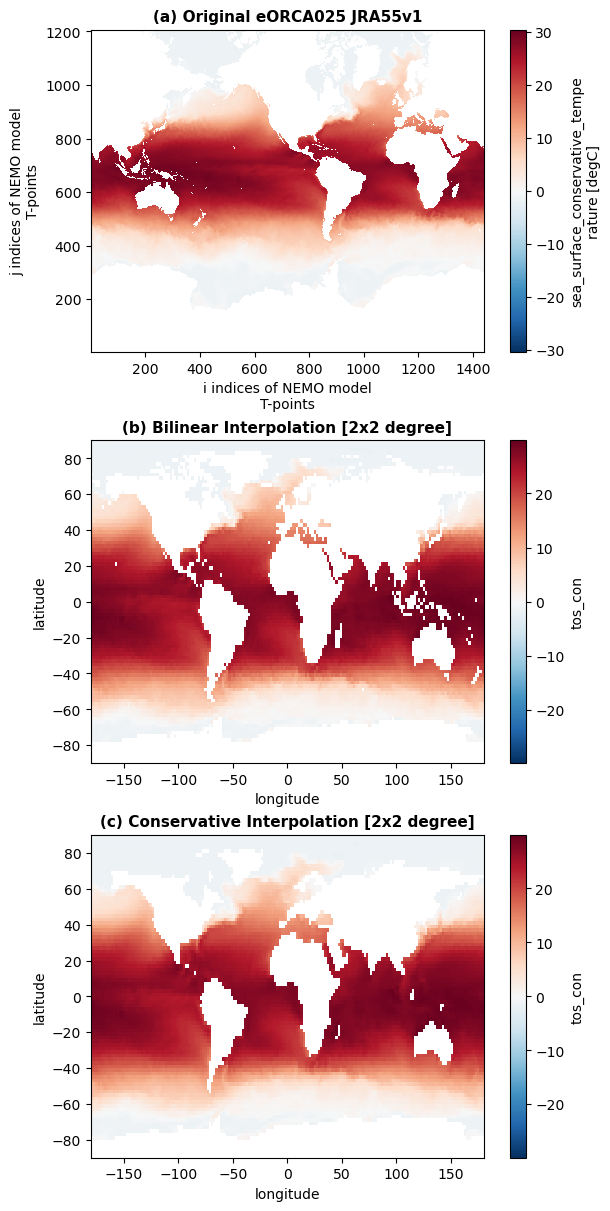

In [10]:
# -- Create a Figure with Robinson projections -- #
fig = plt.figure(figsize=(6, 12), constrained_layout=True)

ax1 = fig.add_subplot(3, 1, 1)
# Plot original eORCA025 JRA55v1 sea surface temperature on native grid:
ds_tos_con['tos_con'].plot(ax=ax1)
plt.title("(a) Original eORCA025 JRA55v1", fontdict={"fontsize": 11, "fontweight": "bold"})

ax2= fig.add_subplot(3, 1, 2)
# Plot bilinearly regridded sea surface temperature on regular 2x2 degree grid:
ds_bilinear['tos_con'].plot(x='lon', y='lat', ax=ax2)
plt.title("(b) Bilinear Interpolation [2x2 degree]", fontdict={"fontsize": 11, "fontweight": "bold"})

ax3 = fig.add_subplot(3, 1, 3)
# Plot conservatively regridded sea surface temperature on regular 2x2 degree grid:
ds_conservative['tos_con'].plot(x='lon', y='lat', ax=ax3)
plt.title("(c) Conservative Interpolation [2x2 degree]", fontdict={"fontsize": 11, "fontweight": "bold"})

**Comparing the plots above, we can see that bilinear interpolation introduces some additional NaN values compared with conservative interpolation in regions where the bilinear 4-grid cell stencil of ocean (unmasked) grid cells are invalid due to one or more land grid cells being included (i.e., near coastlines).**